# Face_mask detection

### Import necessary libraries

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import glob


### Fetch the image data

In [2]:
with_mask  = glob.glob('with_mask 1/with_mask 1/*.jpg')
without_mask = glob.glob('without_mask/without_mask/*.jpg')

In [3]:
len(with_mask)

1696

In [4]:
len(without_mask)

1792

### Store all the images inside a list and create a list with the corresponding labels

In [5]:
image = []
label = []
for i in with_mask:
    img = plt.imread(i)
    image.append(img)
    label.append(0)

for i in without_mask:
    img = plt.imread(i)
    image.append(img)
    label.append(1)


#### Use shuffle function from sklearn utils

In [6]:
image, label = shuffle(image,label, random_state = 100)

### Plot a few images from our shuffled list with its corresponding label 

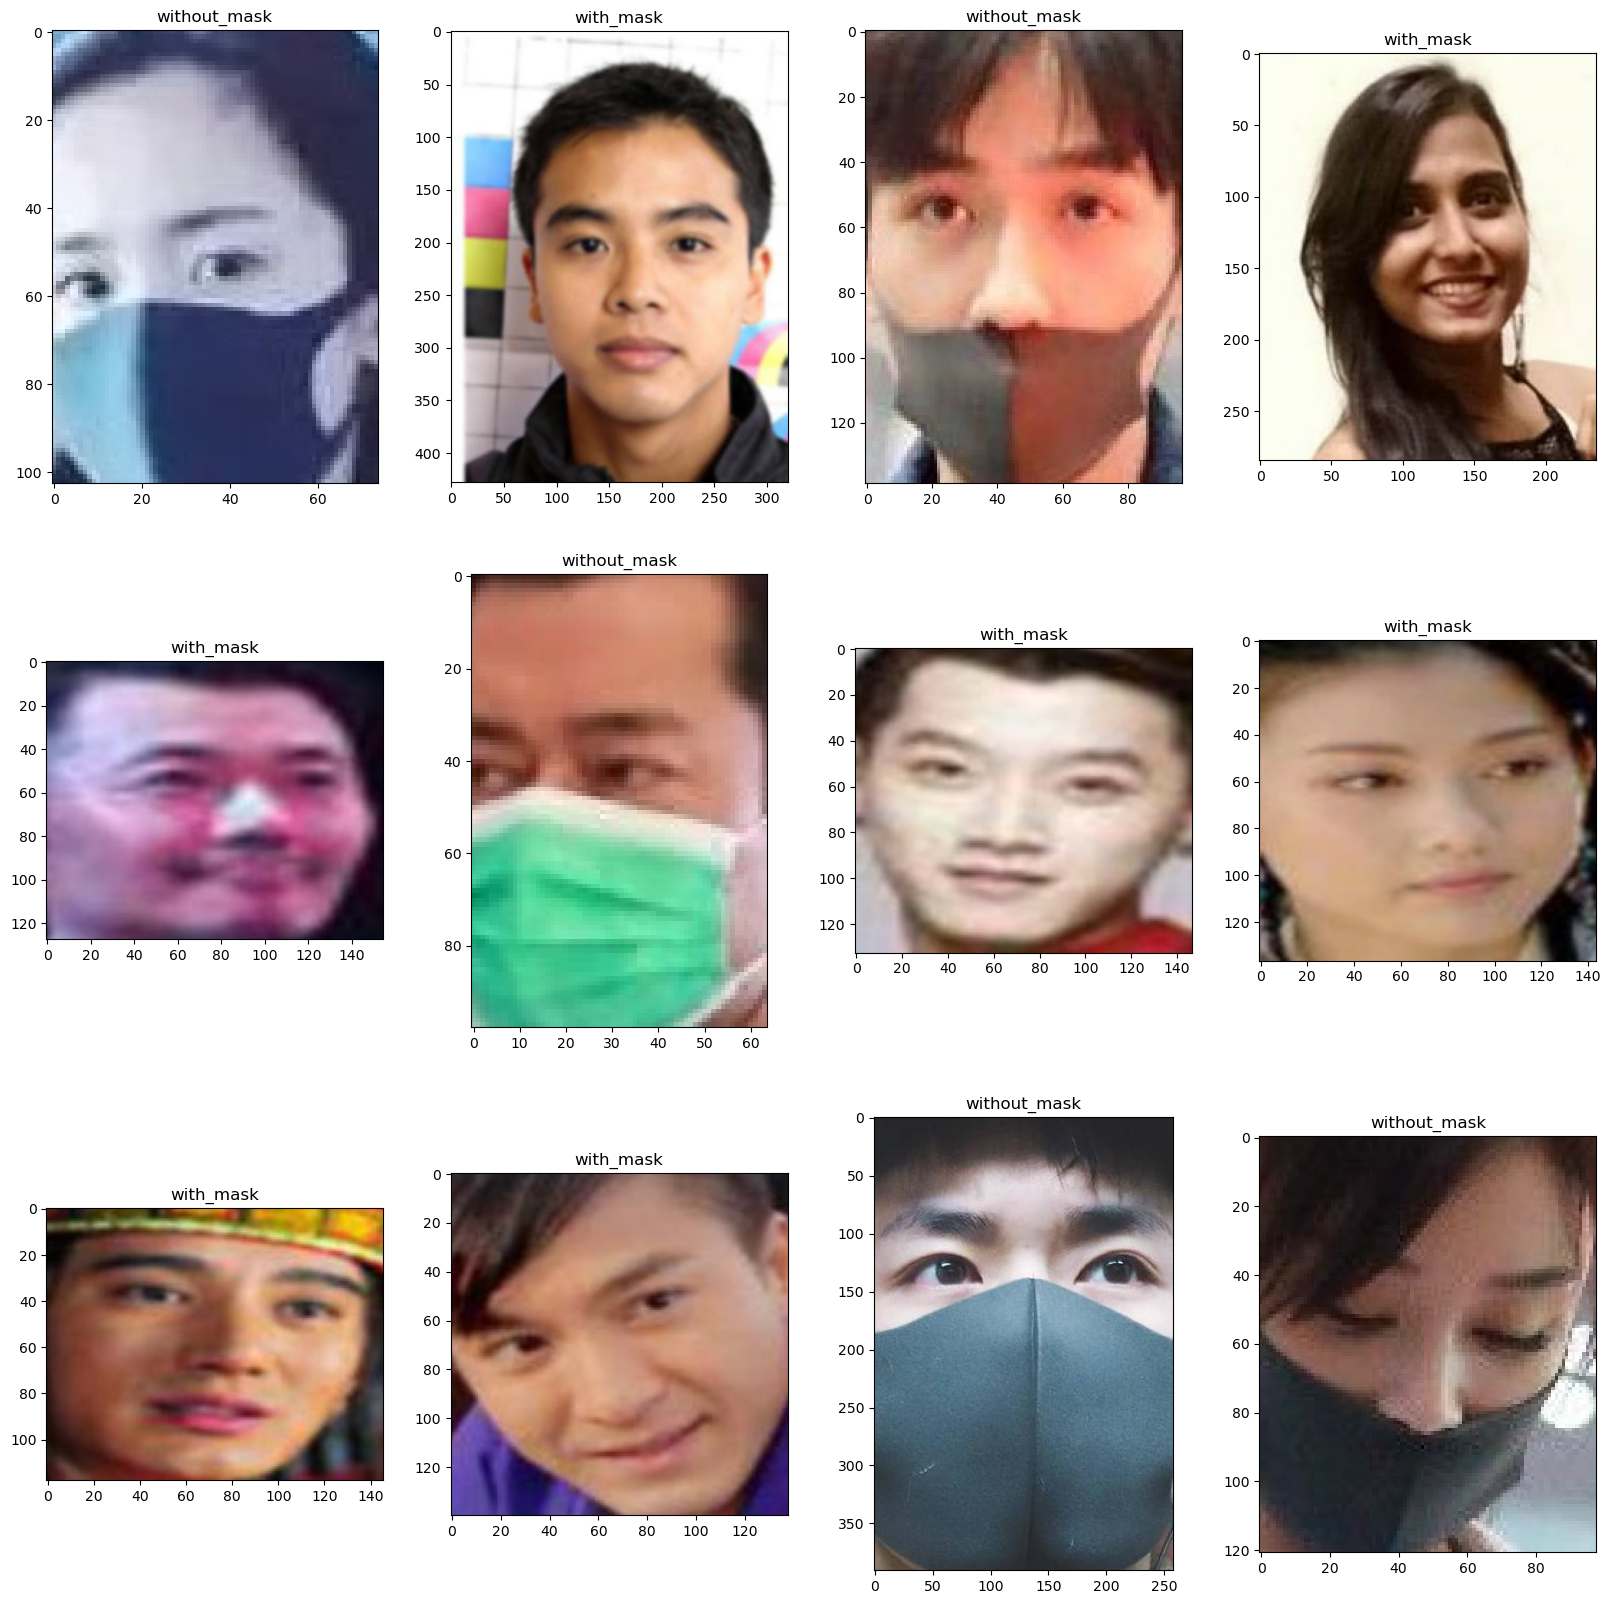

In [7]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 1:
        plt.title('with_mask')
    else:
        plt.title('without_mask')

### Resize the images to 64X64

In [8]:
X = []

for i in image:
    X.append(resize(i,(64,64,3)))
    
X = np.array(X)

### Plot some of the resized images

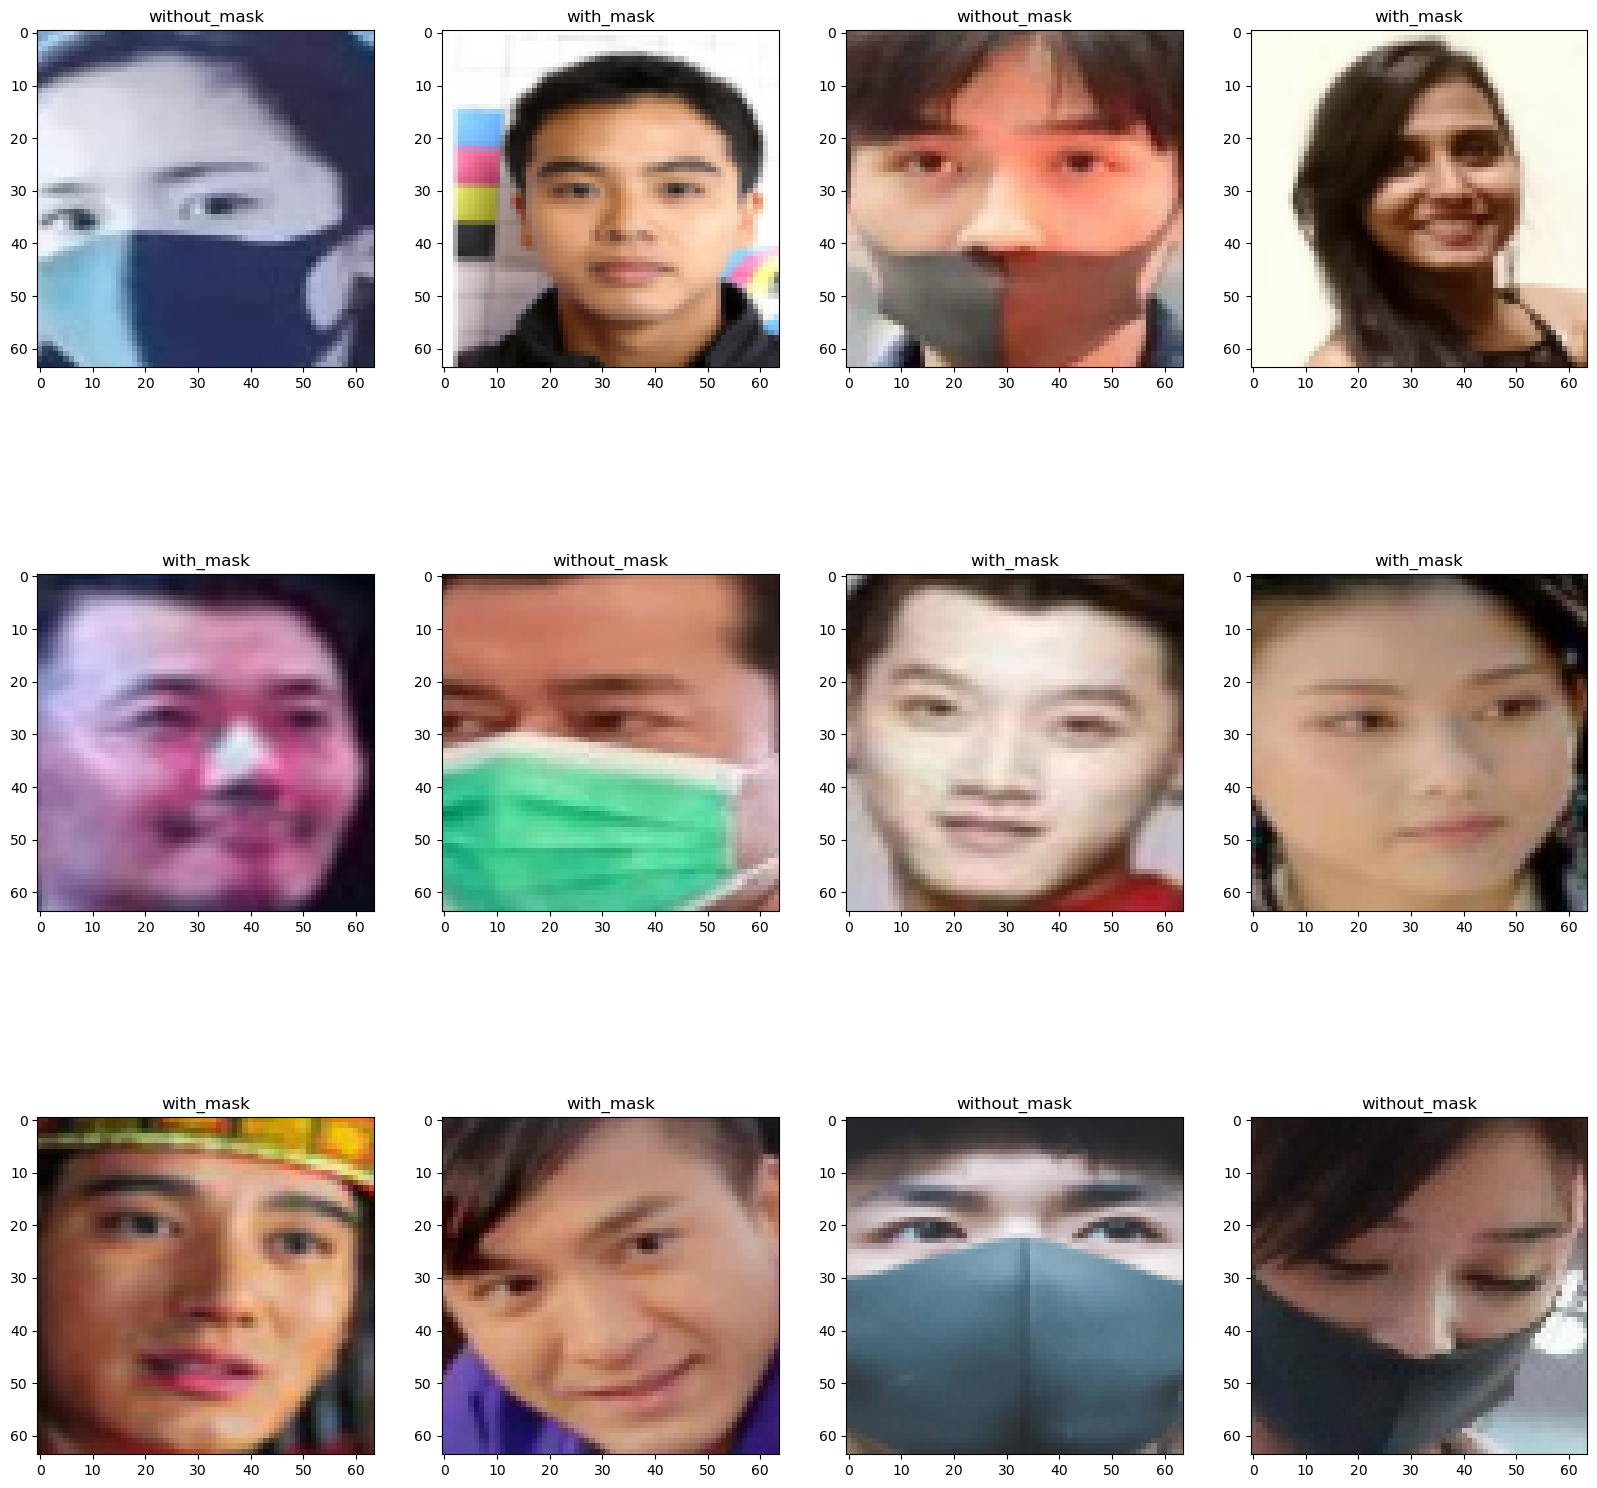

In [9]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X[i])
    if label[i] == 1:
        plt.title('with_mask')
    else:
        plt.title('without_mask')

### Check the datatype of X and Label

In [10]:
print(type(X))
print(type(label))

<class 'numpy.ndarray'>
<class 'list'>


In [11]:
y = np.array(label)

### Split the dataset into Training and Testing set

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2)

### Create Keras Sequential model with 2 convolution layer, Flatten and a Hidden layer

In [15]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16, (3,3), activation = 'relu', input_shape = (64, 64, 3)),
    keras.layers.MaxPool2D(2,2),
    
    keras.layers.Conv2D(32,(3,3), activation = 'relu'),
    keras.layers.MaxPool2D(2,2),
    
    keras.layers.Flatten(),
    
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(1, activation = 'sigmoid')
])

### Compile our model

In [16]:
model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

### Check model summary

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,625 (1.55 MB)

 Trainable params: 406,625 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

### Train our model with X_train and y_train

In [20]:
model.fit(X_train,y_train, epochs=10, steps_per_epoch=3, validation_split=0.1)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 499ms/step - accuracy: 0.9602 - loss: 0.1169 - val_accuracy: 0.9391 - val_loss: 0.1784
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 467ms/step - accuracy: 0.9582 - loss: 0.1170 - val_accuracy: 0.9498 - val_loss: 0.1591
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 497ms/step - accuracy: 0.9586 - loss: 0.1112 - val_accuracy: 0.9319 - val_loss: 0.1934
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step - accuracy: 0.9610 - loss: 0.1120 - val_accuracy: 0.9498 - val_loss: 0.1569
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step - accuracy: 0.9622 - loss: 0.1101 - val_accuracy: 0.9355 - val_loss: 0.1695
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 454ms/step - accuracy: 0.9610 - loss: 0.1088 - val_accuracy: 0.9391 - val_loss: 0.1666
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 456ms/step - accuracy: 0.9658 - loss: 0.1040 - val_accuracy: 0.9534 - val_loss: 0.1559
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 475ms/step - accuracy: 0.9661 - loss: 0.1038 - val_accuracy: 0.9391 - val_loss:

### Evaluate our Model

In [22]:
model.evaluate(X_train,y_train)

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9663 - loss: 0.1013 


[0.10128754377365112, 0.9663082361221313]

### Make predictions with X_test

In [24]:
prediction = model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [25]:
prediction[:5]

array([[0.9812851 ],
       [0.9127204 ],
       [0.00284208],
       [0.9478505 ],
       [0.98375344]], dtype=float32)

#### Our prediction is numbers ranging from 0 to 1. We can convert values less than 0.5 to 0 and rest to 1.

In [26]:
pred = []

for i in prediction:
    if i > 0.5:
        pred.append(0)
    else:
        pred.append(1)

In [27]:
pred

[0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,


### Plot X_test along with label from our prediction

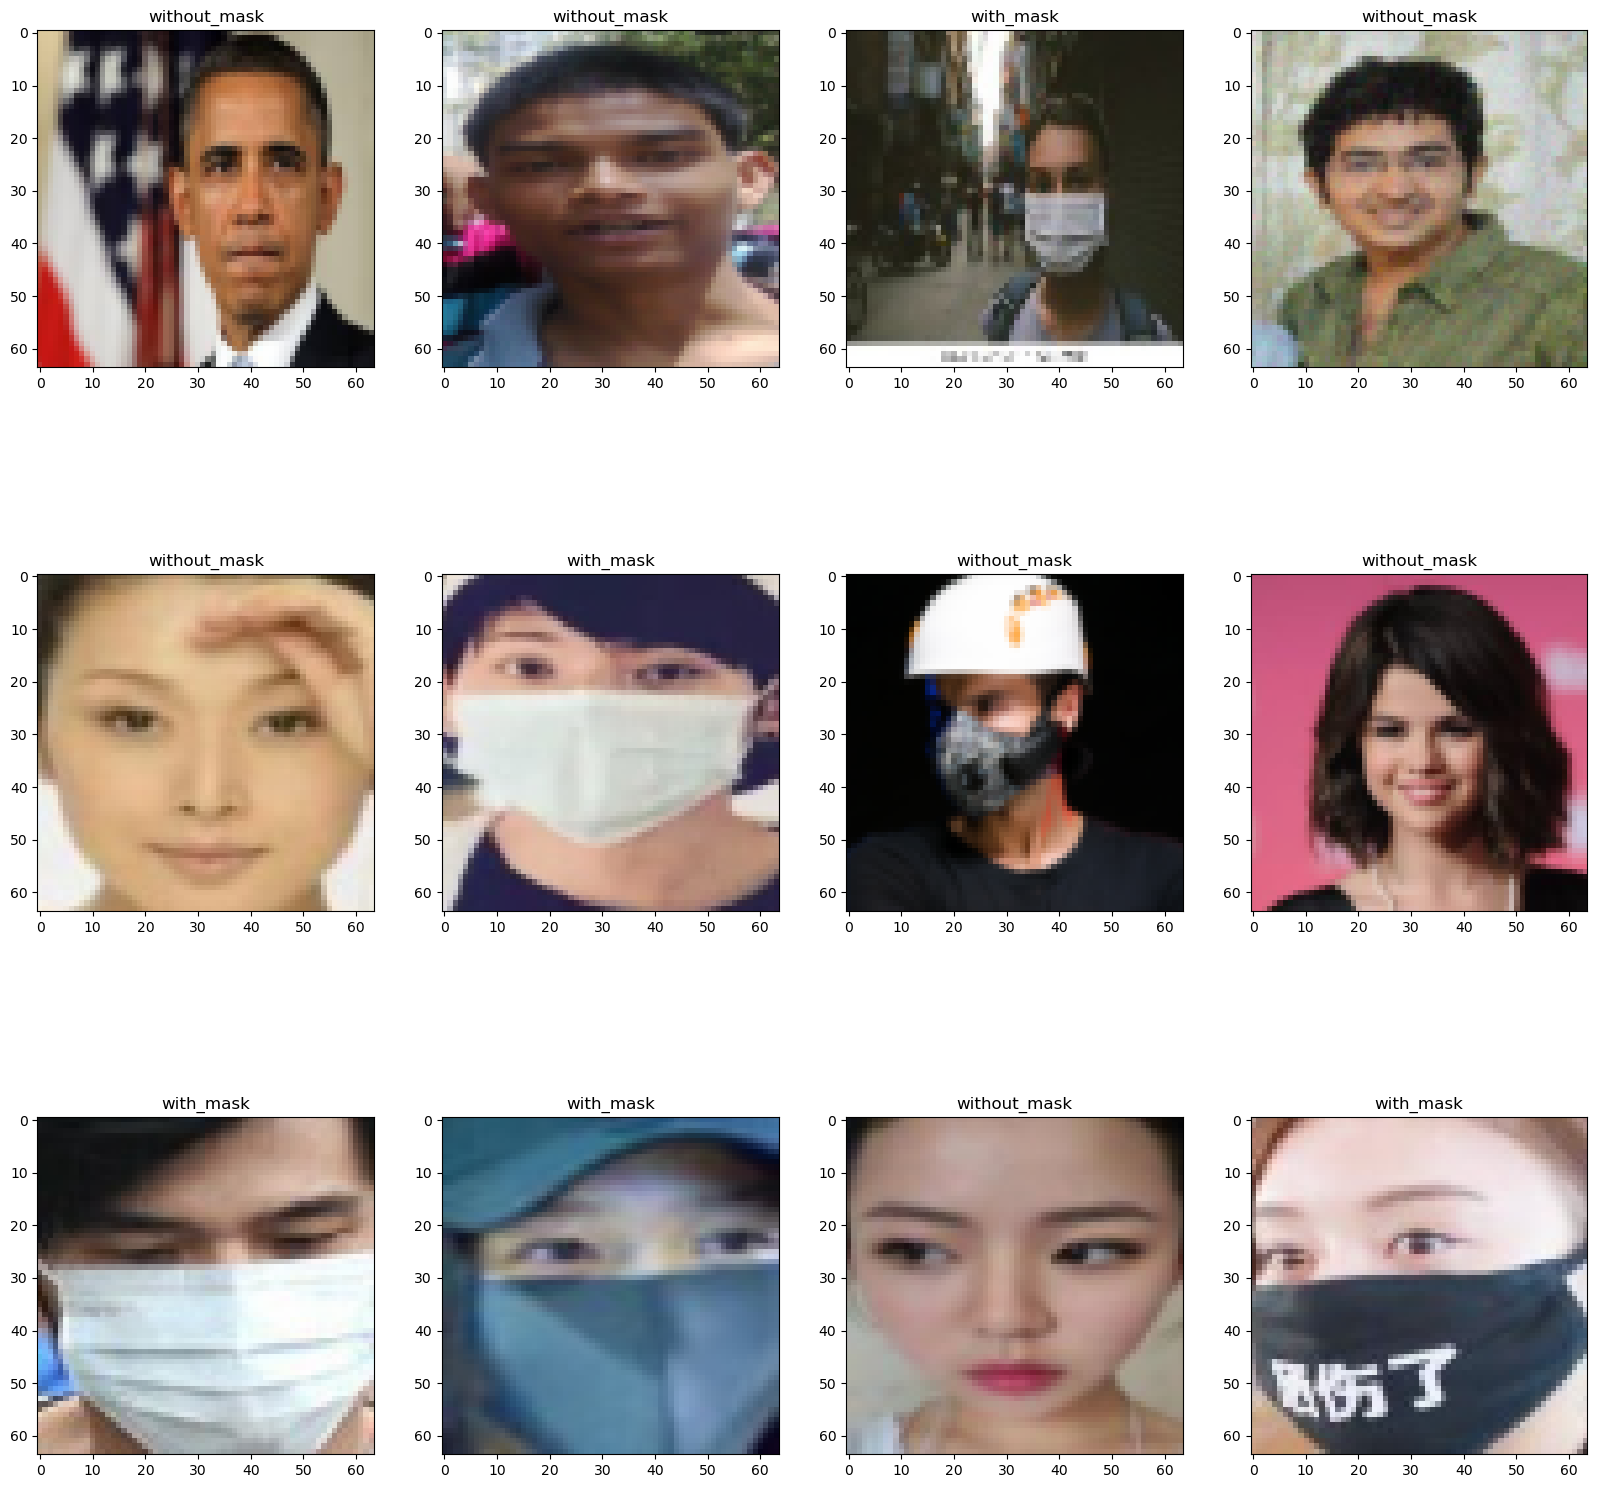

In [37]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    if pred[i] == 1:
        plt.title('with_mask')
    else:
        plt.title('without_mask')

### Plot confusion matrix on a heatmap

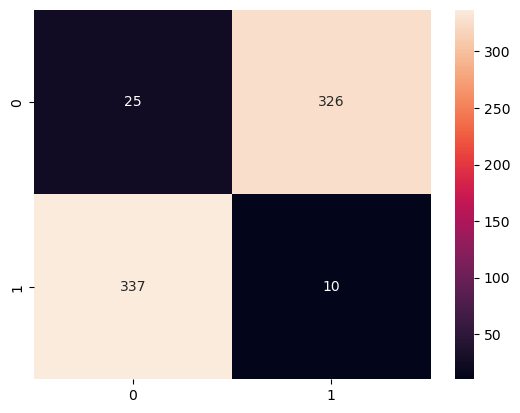

In [34]:
sns.heatmap(confusion_matrix(y_test,pred), annot = True,fmt='d')
plt.show()

### classification

In [35]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.07      0.07      0.07       351
           1       0.03      0.03      0.03       347

    accuracy                           0.05       698
   macro avg       0.05      0.05      0.05       698
weighted avg       0.05      0.05      0.05       698

